# Домашнее задание: Деревья и ансамбли
В этом задании вы примените **деревья решений, случайный лес и бустинг** для решения реальной классификации.
Мы будем работать с датасетом о предсказании оттока клиентов банка.

In [195]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay


## 1. Загрузка и первичный обзор данных

## 📑 Описание признаков датасета Telco Customer Churn

1. **gender** – пол клиента (`Male` или `Female`).  
2. **SeniorCitizen** – является ли клиент пожилым человеком (`1` – да, `0` – нет).  
3. **Partner** – есть ли у клиента супруг/супруга (`Yes` или `No`).  
4. **Dependents** – есть ли иждивенцы (дети, родственники) (`Yes` или `No`).  
5. **tenure** – срок обслуживания в компании (количество месяцев).  
6. **PhoneService** – подключена ли телефонная линия (`Yes` или `No`).  
7. **MultipleLines** – наличие нескольких телефонных линий (`No`, `Yes`, `No phone service`).  
8. **InternetService** – тип интернет-сервиса (`DSL`, `Fiber optic`, `No`).  
9. **OnlineSecurity** – наличие услуги онлайн-безопасности (`Yes`, `No`, `No internet service`).  
10. **OnlineBackup** – наличие услуги онлайн-бэкапа данных (`Yes`, `No`, `No internet service`).  
11. **DeviceProtection** – наличие услуги защиты устройства (`Yes`, `No`, `No internet service`).  
12. **TechSupport** – наличие услуги технической поддержки (`Yes`, `No`, `No internet service`).  
13. **StreamingTV** – наличие услуги потокового ТВ (`Yes`, `No`, `No internet service`).  
14. **StreamingMovies** – наличие услуги потокового кино (`Yes`, `No`, `No internet service`).  
15. **Contract** – тип контракта (`Month-to-month`, `One year`, `Two year`).  
16. **PaperlessBilling** – используется ли безбумажная оплата (`Yes` или `No`).  
17. **PaymentMethod** – метод оплаты (`Electronic check`, `Mailed check`, `Bank transfer (automatic)`, `Credit card (automatic)`).  
18. **MonthlyCharges** – ежемесячные расходы клиента (в долларах).  
19. **TotalCharges** – общая сумма расходов клиента за всё время (в долларах).  
20. **Churn** – целевая переменная: ушёл ли клиент (`Yes` – ушёл, `No` – остался).  


In [196]:
# Данные возьмем из открытого источника (Churn dataset)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Посмотрим на данные
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. EDA (разведочный анализ данных)
- Посмотрите на размеры датасета
- Проверьте наличие пропусков. Если есть пропуски, заполните их
- Посчитайте распределение целевой переменной (`Churn`)

Посмотрим на размер датасета

In [197]:
df.shape


(7043, 21)

посмотрим на типы признаков

In [198]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

посмотрим есть ли пропуски в данных

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

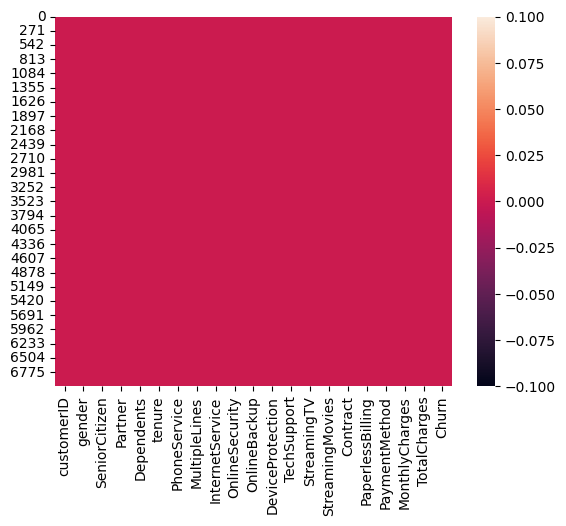

In [199]:
import seaborn as sns

sns.heatmap(df.isnull())

df.isnull().sum()

удалим CustomerId из данных

In [200]:
df = df.drop("customerID", axis=1)

распределение целевой переменной

<Axes: xlabel='Churn', ylabel='Count'>

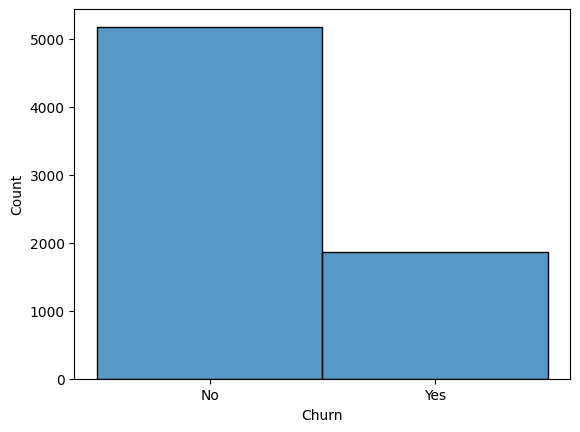

In [201]:
sns.histplot(df["Churn"])

Выраженный дисбаланс классов в два раза.

преобразуем целевой признак в 1/0, где 1 - клиент уйдет , 0 - нет

преобразуем числовые признаки из str а float: TotalCharges

In [202]:
df["Churn"] = df["Churn"].map(lambda x: 1 if x == "Yes" else 0)
df["TotalCharges"] = df["TotalCharges"].str.replace(' ', '0').astype(float)

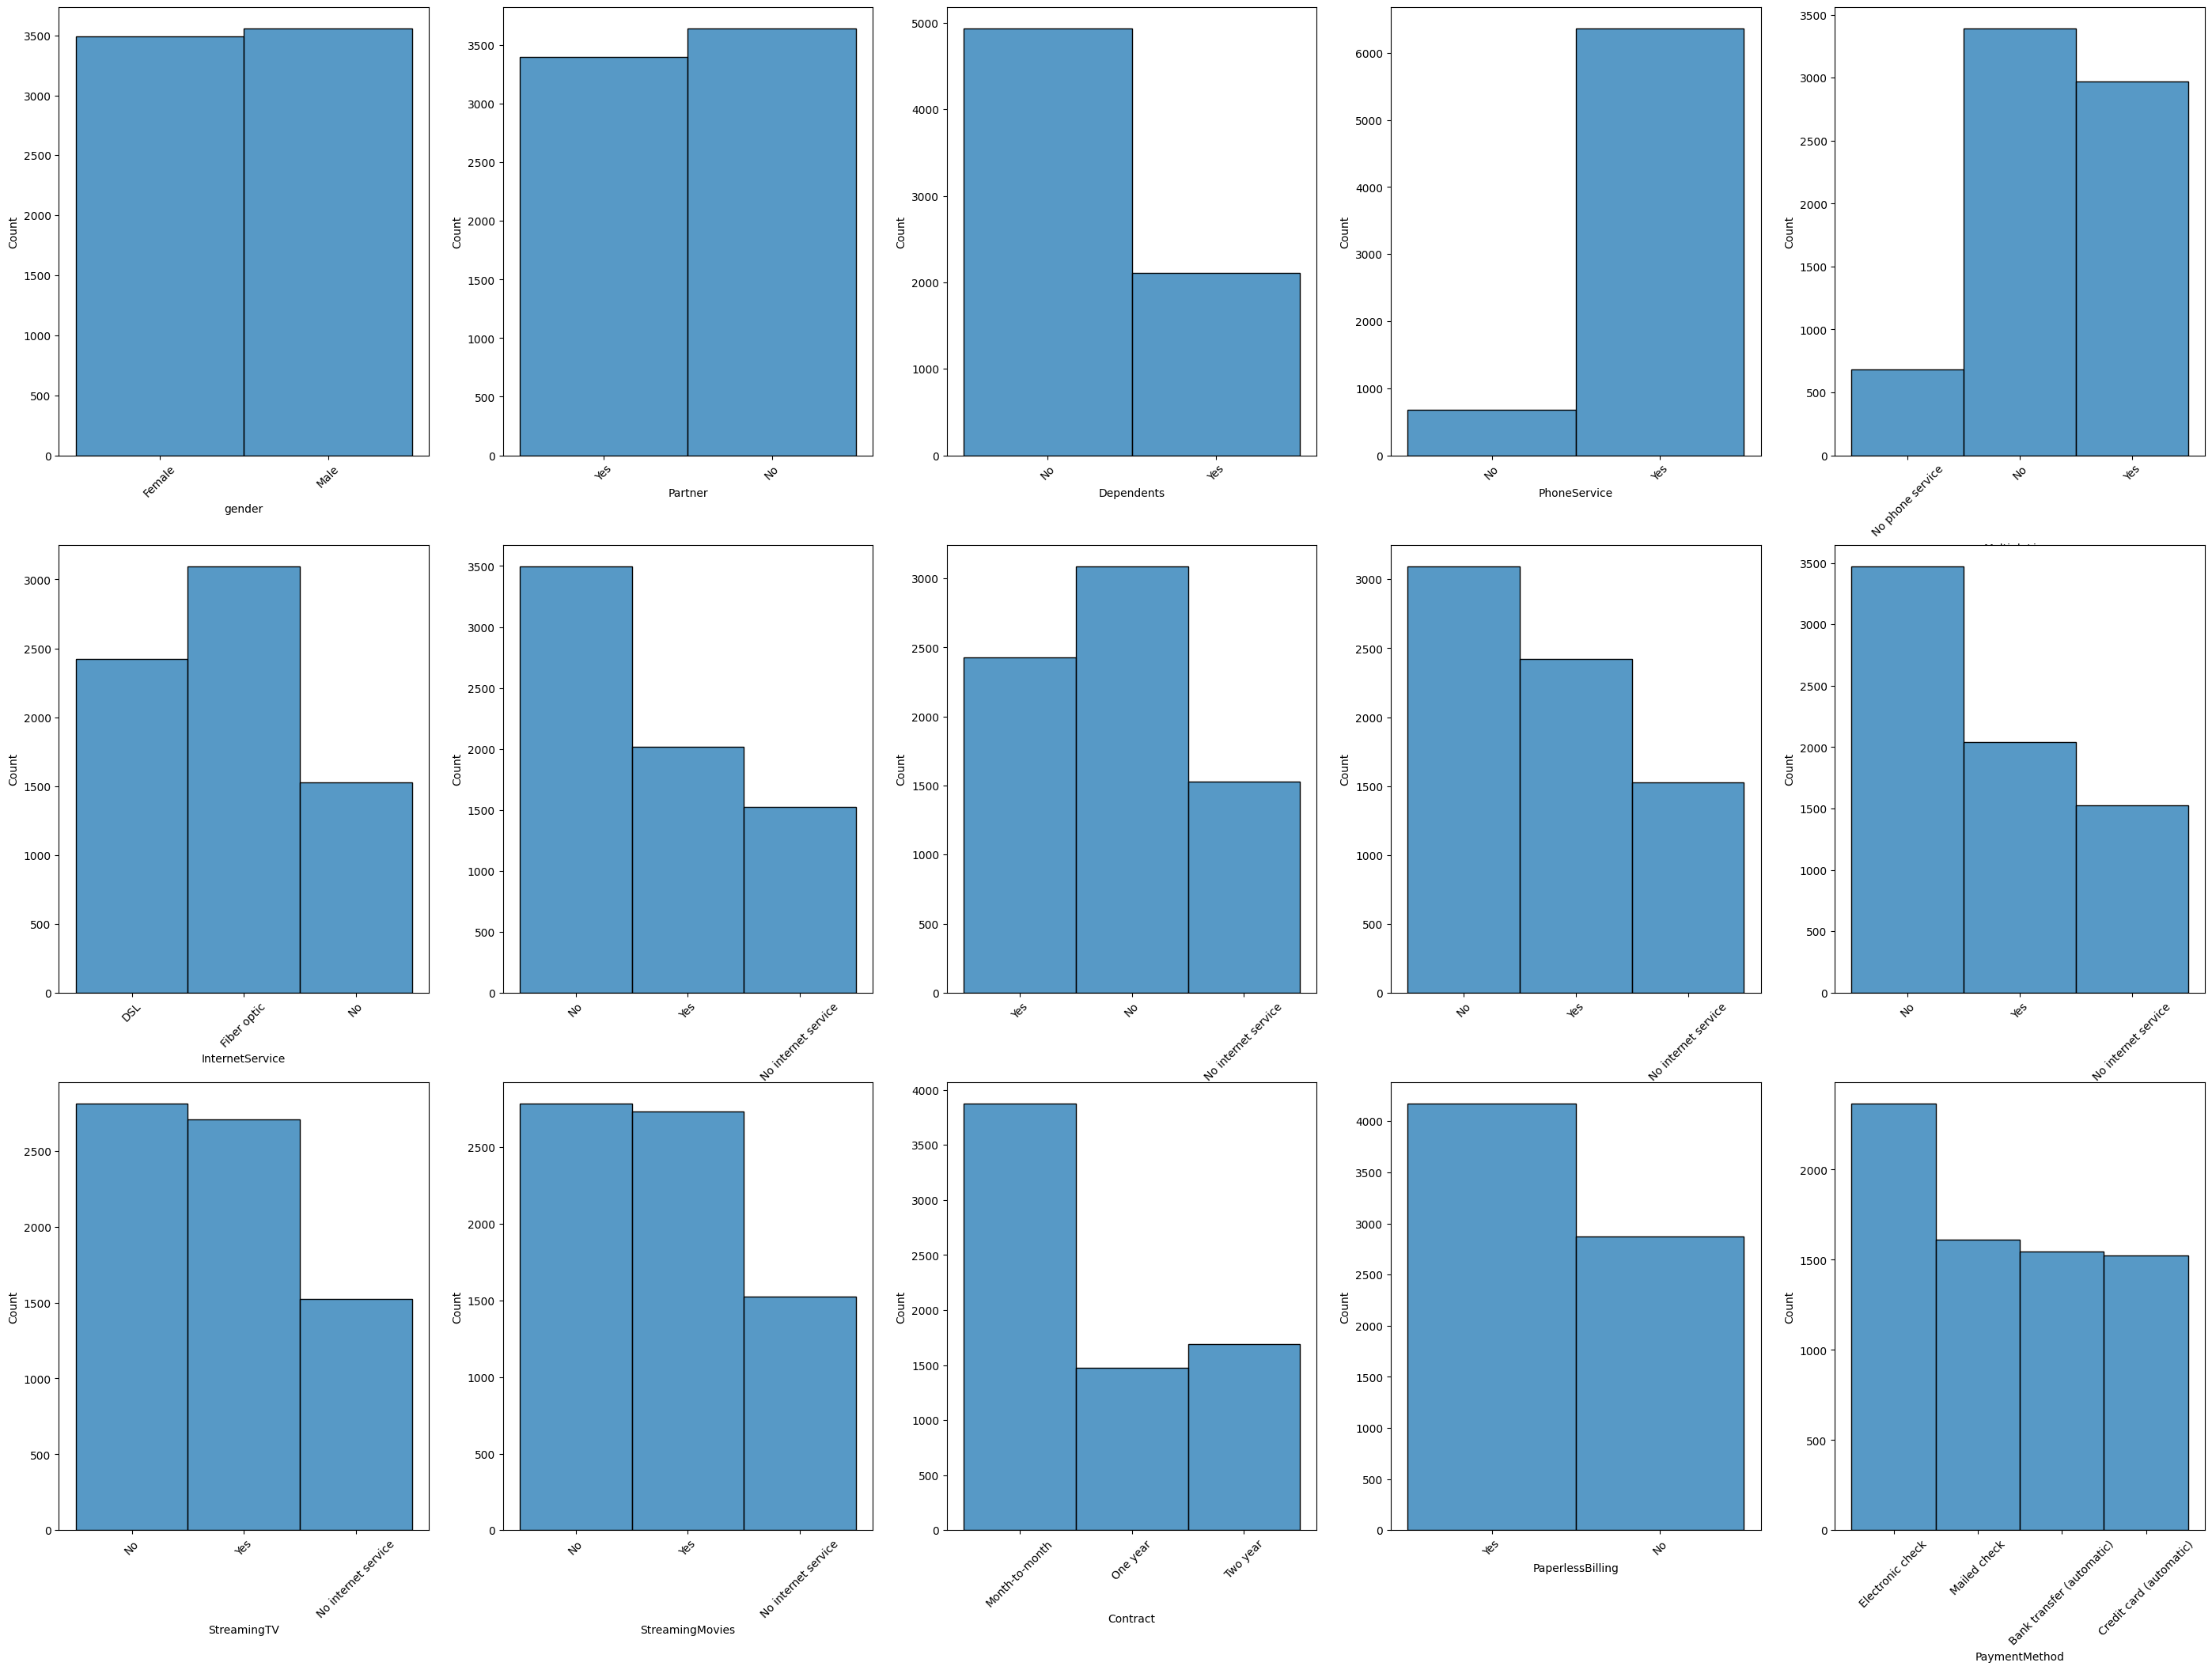

In [203]:
categorical_columns = df.select_dtypes(exclude=["int", "float"]).columns

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(35,25))

for col, ax in zip(categorical_columns, axes.ravel()):
    sns.histplot(data=df, x=col, ax=ax)
    ax.tick_params(axis='x', rotation=45)

## 3. Предобработка данных
Разделите выборку на train/test части

In [204]:
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder, OneHotEncoder

def preprocess_data(data, cat_columns) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    y = data["Churn"]
    X = data.drop(columns=["Churn"])
    num_columns = X.columns.difference(cat_columns, sort=False)
    
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    
    train_cat = encoder.fit_transform(X_train[cat_columns])
    test_cat = encoder.transform(X_test[cat_columns])
    
    features_names = [
        *encoder.get_feature_names_out(cat_columns),
        *num_columns
    ]
    
    X_train = pd.DataFrame(
        np.hstack([train_cat, X_train[num_columns].to_numpy()]),
        columns=features_names,
        index=X_train.index
    )
    
    X_test = pd.DataFrame(
            np.hstack([test_cat, X_test[num_columns].to_numpy()]),
            columns=features_names,
            index=X_test.index
        )
    
    print(f"Размер тренировочной выборки: {X_train.shape}")
    print(f"Размер тестовой выборки: {X_test.shape}")
    
    return X_train, X_test, y_train, y_test

In [205]:
cat_columns = df.select_dtypes(exclude=["int", "float"]).columns.to_list()

In [206]:
X_train, X_test, y_train, y_test = preprocess_data(df.copy(), cat_columns)

Размер тренировочной выборки: (5634, 45)
Размер тестовой выборки: (1409, 45)


## 4. Decision Tree

Обучите дерево решений (ограничьте глубину до 5)

In [207]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Визуализируйте дерево (используйте для визуализации функцию plot_tree)

[Text(0.5, 0.9166666666666666, 'x[32] <= 0.5\ngini = 0.39\nsamples = 5634\nvalue = [4139, 1495]'),
 Text(0.25, 0.75, 'x[43] <= 93.675\ngini = 0.125\nsamples = 2532\nvalue = [2363, 169]'),
 Text(0.375, 0.8333333333333333, 'True  '),
 Text(0.125, 0.5833333333333334, 'x[14] <= 0.5\ngini = 0.076\nsamples = 1904\nvalue = [1829, 75]'),
 Text(0.0625, 0.4166666666666667, 'x[33] <= 0.5\ngini = 0.047\nsamples = 1505\nvalue = [1469, 36]'),
 Text(0.03125, 0.25, 'x[17] <= 0.5\ngini = 0.024\nsamples = 924\nvalue = [913, 11]'),
 Text(0.015625, 0.08333333333333333, 'gini = 0.018\nsamples = 786\nvalue = [779, 7]'),
 Text(0.046875, 0.08333333333333333, 'gini = 0.056\nsamples = 138\nvalue = [134, 4]'),
 Text(0.09375, 0.25, 'x[43] <= 72.175\ngini = 0.082\nsamples = 581\nvalue = [556, 25]'),
 Text(0.078125, 0.08333333333333333, 'gini = 0.054\nsamples = 470\nvalue = [457, 13]'),
 Text(0.109375, 0.08333333333333333, 'gini = 0.193\nsamples = 111\nvalue = [99, 12]'),
 Text(0.1875, 0.4166666666666667, 'x[34] <=

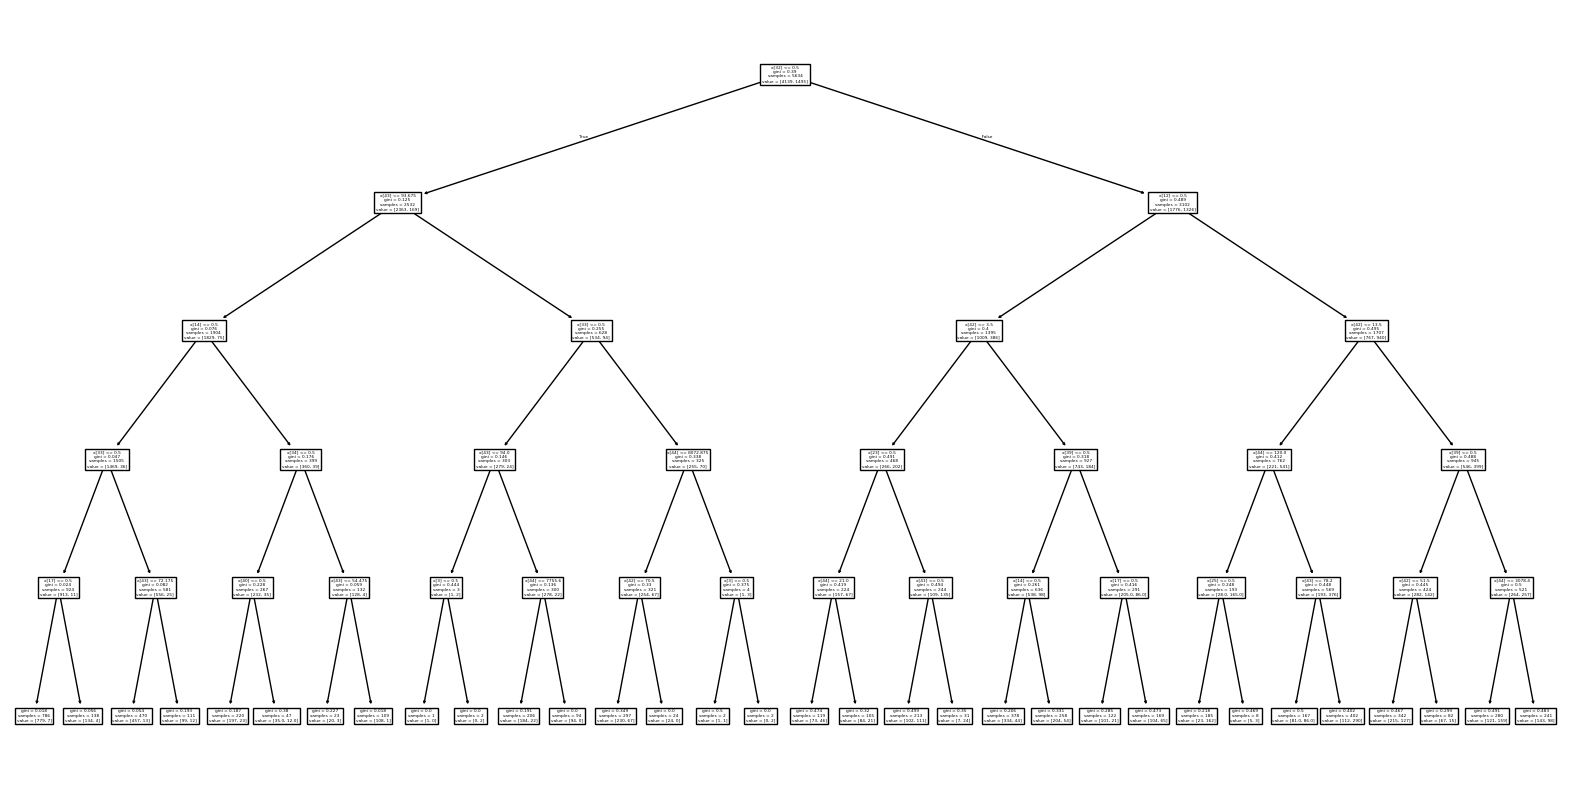

In [208]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model)

### Метрики качества

Посчитайте метрики Accuracy, F1, ROC-AUC

In [209]:

y_pred = tree_model.predict(X_test)
y_pred_prob = tree_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1-score: {f1_score(y_test, y_pred)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob)}")

Accuracy: 0.7984386089425124
F1-score: 0.5988700564971752
ROC-AUC: 0.830278488206877


## 5. Random Forest

Обучите случайный лес

In [210]:
forest_model = RandomForestClassifier(n_estimators=100,  max_depth=5, random_state=42)

forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

Оцените метрики для случайного леса

In [211]:
y_pred = forest_model.predict(X_test)
y_pred_prob = forest_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1-score: {f1_score(y_test, y_pred)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob)}")

Accuracy: 0.7955997161107168
F1-score: 0.5294117647058824
ROC-AUC: 0.8403149138443256


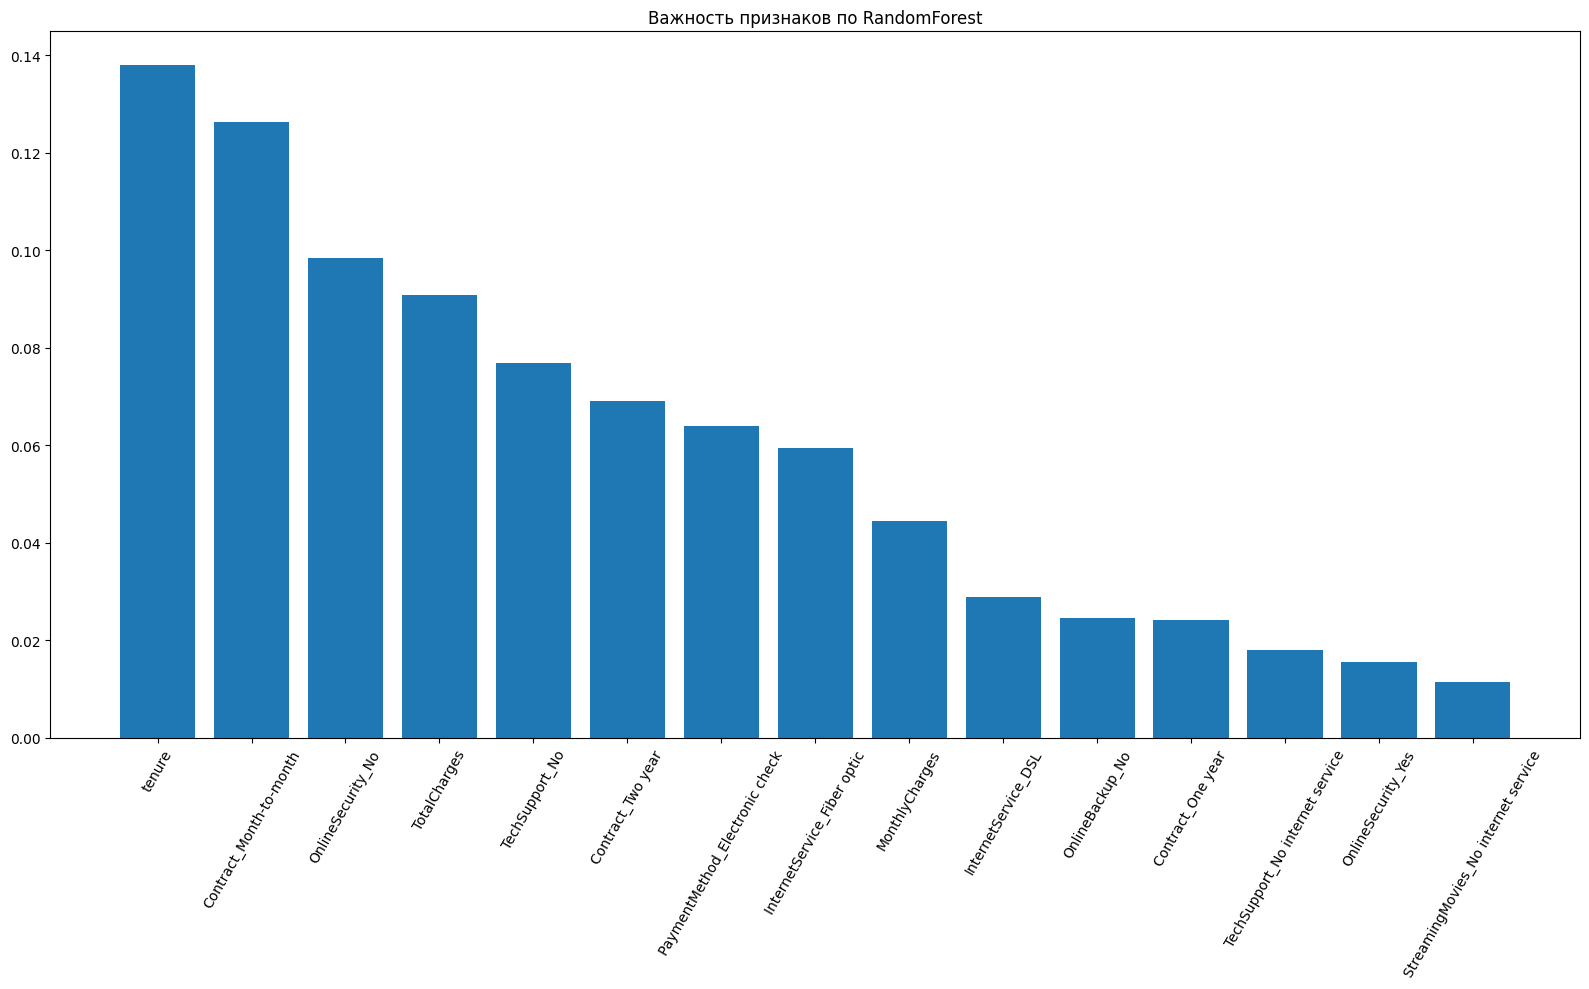

In [212]:
ft_importance = forest_model.feature_importances_
order = np.argsort(ft_importance)[::-1][:15]

plt.figure(figsize=(16,10))
plt.title("Важность признаков по RandomForest")
plt.bar(
    X_train.columns[order],
    ft_importance[order]
)
plt.xticks(rotation=60)
plt.tight_layout()

## 6. Градиентные бустинги

Обучите модели градиентного бустинга: XGBoost, LightGBM, CatBoost. Каждая из перечисленных библиотек на практике имеет свои тонкости и особенности. Посмотрите ноутбуки с подробным разбором этих бустингов:

**CatBoost** - https://colab.research.google.com/github/Ivanich-spb/CDScourse_tasks/blob/main/notebooks/4_1_CatBoost.ipynb#scrollTo=KE1xOIa1EYmB

**LightGBM** - https://colab.research.google.com/github/Ivanich-spb/CDScourse_tasks/blob/main/notebooks/4_2_LightGBM.ipynb

**XGBoost** - https://colab.research.google.com/github/Ivanich-spb/CDScourse_tasks/blob/main/notebooks/4_3_XGBoost.ipynb  

Одной из таких особенностей является возможность обернуть набор данных в специальные обёртки-классы, которые оптимизирует датасет по памяти и времени обучения:

<p id="c1"></p>

* `CatBoost` -> `Pool`
* `LightGBM` -> `Dataset`
* `XGBoost` -> `DMatrix`

Оберните свой набор данных в соответствующие классы и обучите градиентные бустинги. (В приложенных ноутбуках есть примеры). Посчитайте метрики

In [213]:
y = df["Churn"]
X = df.drop(columns=["Churn"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

for col in cat_columns:
    X_train[col] = X_train[col].astype("category")

    X_test[col] = X_test[col].astype("category")

In [214]:
from catboost import Pool, CatBoostClassifier

import catboost as ct
import xgboost as xgb
import lightgbm as lgbm

train_catboost = Pool(X_train, label=y_train, cat_features=cat_columns)
test_catboost = Pool(X_test, label=y_test, cat_features=cat_columns)

train_xgboost = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
test_xgboost = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

train_lightgbm = lgbm.Dataset(X_train, label=y_train, categorical_feature=cat_columns)

In [215]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

params_xgb = {
    "objective": "binary:logistic", 
    "seed": 42,
    "max_depth": 8,
    "reg_lambda": 0.001,
    "subsample": 0.9,
    "scale_pos_weight": pos_weight
    }

params_lgbm = {"objective": "binary", "seed": 42, "scale_pos_weight": pos_weight}

cat_model = CatBoostClassifier(random_state=42, max_depth=7, n_estimators=200, class_weights={0: 1, 1: pos_weight}, learning_rate=0.02)
cat_model.fit(train_catboost)

xgb_model = xgb.train(params=params_xgb, dtrain=train_xgboost, num_boost_round=300)
lgbm_model = lgbm.train(params=params_lgbm, train_set=train_lightgbm)

0:	learn: 0.6836063	total: 12.6ms	remaining: 2.5s
1:	learn: 0.6743539	total: 20.6ms	remaining: 2.03s
2:	learn: 0.6665845	total: 28.2ms	remaining: 1.85s
3:	learn: 0.6593442	total: 34.6ms	remaining: 1.69s
4:	learn: 0.6533714	total: 39.3ms	remaining: 1.53s
5:	learn: 0.6453132	total: 46.1ms	remaining: 1.49s
6:	learn: 0.6384394	total: 51.6ms	remaining: 1.42s
7:	learn: 0.6335884	total: 55.3ms	remaining: 1.33s
8:	learn: 0.6278650	total: 60.8ms	remaining: 1.29s
9:	learn: 0.6230055	total: 65.4ms	remaining: 1.24s
10:	learn: 0.6168066	total: 72.6ms	remaining: 1.25s
11:	learn: 0.6124322	total: 76.6ms	remaining: 1.2s
12:	learn: 0.6072083	total: 82.3ms	remaining: 1.18s
13:	learn: 0.6012962	total: 89.9ms	remaining: 1.19s
14:	learn: 0.5964477	total: 96.5ms	remaining: 1.19s
15:	learn: 0.5915234	total: 102ms	remaining: 1.17s
16:	learn: 0.5872532	total: 106ms	remaining: 1.14s
17:	learn: 0.5826496	total: 112ms	remaining: 1.13s
18:	learn: 0.5795786	total: 115ms	remaining: 1.09s
19:	learn: 0.5755554	total: 

In [216]:
from sklearn.metrics import classification_report

y_pred_xgb = xgb_model.predict(test_xgboost)
y_pred_prob_xgb = y_pred_xgb
y_pred_xgb = (y_pred_xgb > 0.5).astype(int)

y_pred_lgbm = lgbm_model.predict(X_test)
y_pred_prob_lgbm = y_pred_lgbm
y_pred_lgbm = (y_pred_lgbm > 0.5).astype(int)

y_pred_ct = cat_model.predict(X_test)
y_pred_prob_ct = cat_model.predict_proba(X_test)[:, 1]

print("XGBoost")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print(f"F1-score: {f1_score(y_test, y_pred_xgb)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_xgb)}")
print(classification_report(y_test, y_pred_xgb))
print()

print("LightGBM")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm)}")
print(f"F1-score: {f1_score(y_test, y_pred_lgbm)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_lgbm)}")
print(classification_report(y_test, y_pred_lgbm))
print()

print("CatBoost")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ct)}")
print(f"F1-score: {f1_score(y_test, y_pred_ct)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_ct)}")
print(classification_report(y_test, y_pred_ct))
print()

XGBoost
Accuracy: 0.7650816181689141
F1-score: 0.559254327563249
ROC-AUC: 0.7972680771913508
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1035
           1       0.56      0.56      0.56       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409


LightGBM
Accuracy: 0.7544357700496807
F1-score: 0.6189427312775331
ROC-AUC: 0.8326939471440751
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.77      1409


CatBoost
Accuracy: 0.752306600425834
F1-score: 0.6299045599151644
ROC-AUC: 0.8427665400811182
              precision    recall  f1-score   support

       

## 7. Интерпретация признаков

Постройте график важности признаков для RandomForest и градиентных бустингов. Какие из признаков являются наименее важными?

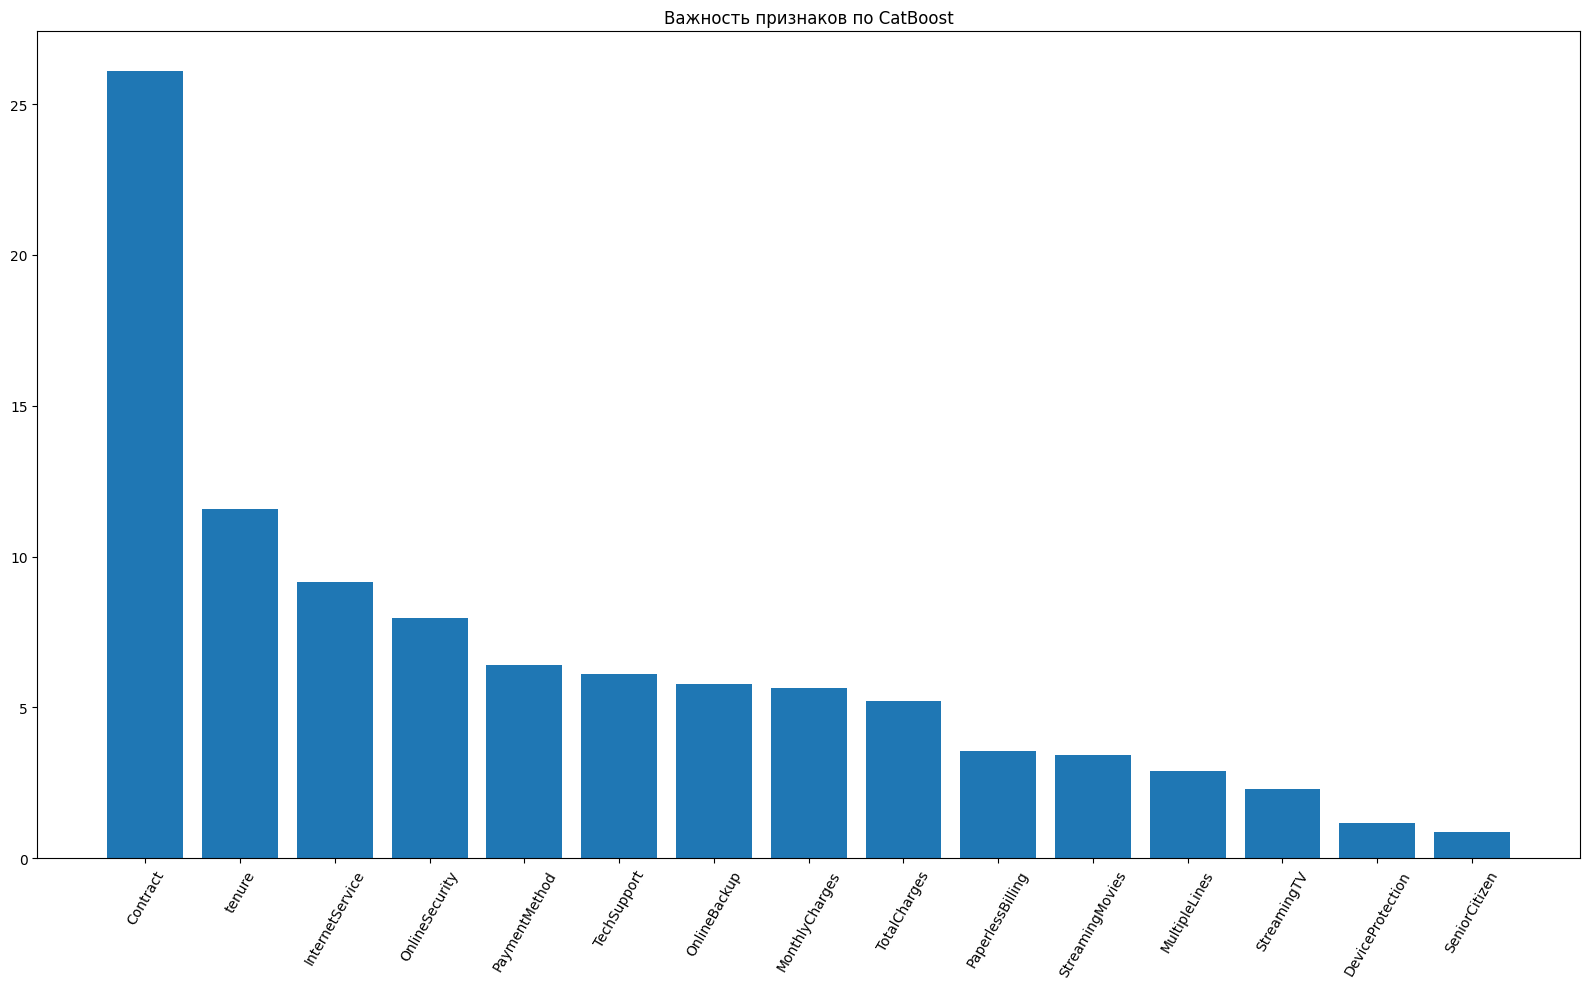

In [217]:
ft_importance = cat_model.feature_importances_
order = np.argsort(ft_importance)[::-1][:15]

plt.figure(figsize=(16,10))
plt.title("Важность признаков по CatBoost")
plt.bar(
    X_train.columns[order],
    ft_importance[order]
)
plt.xticks(rotation=60)
plt.tight_layout()

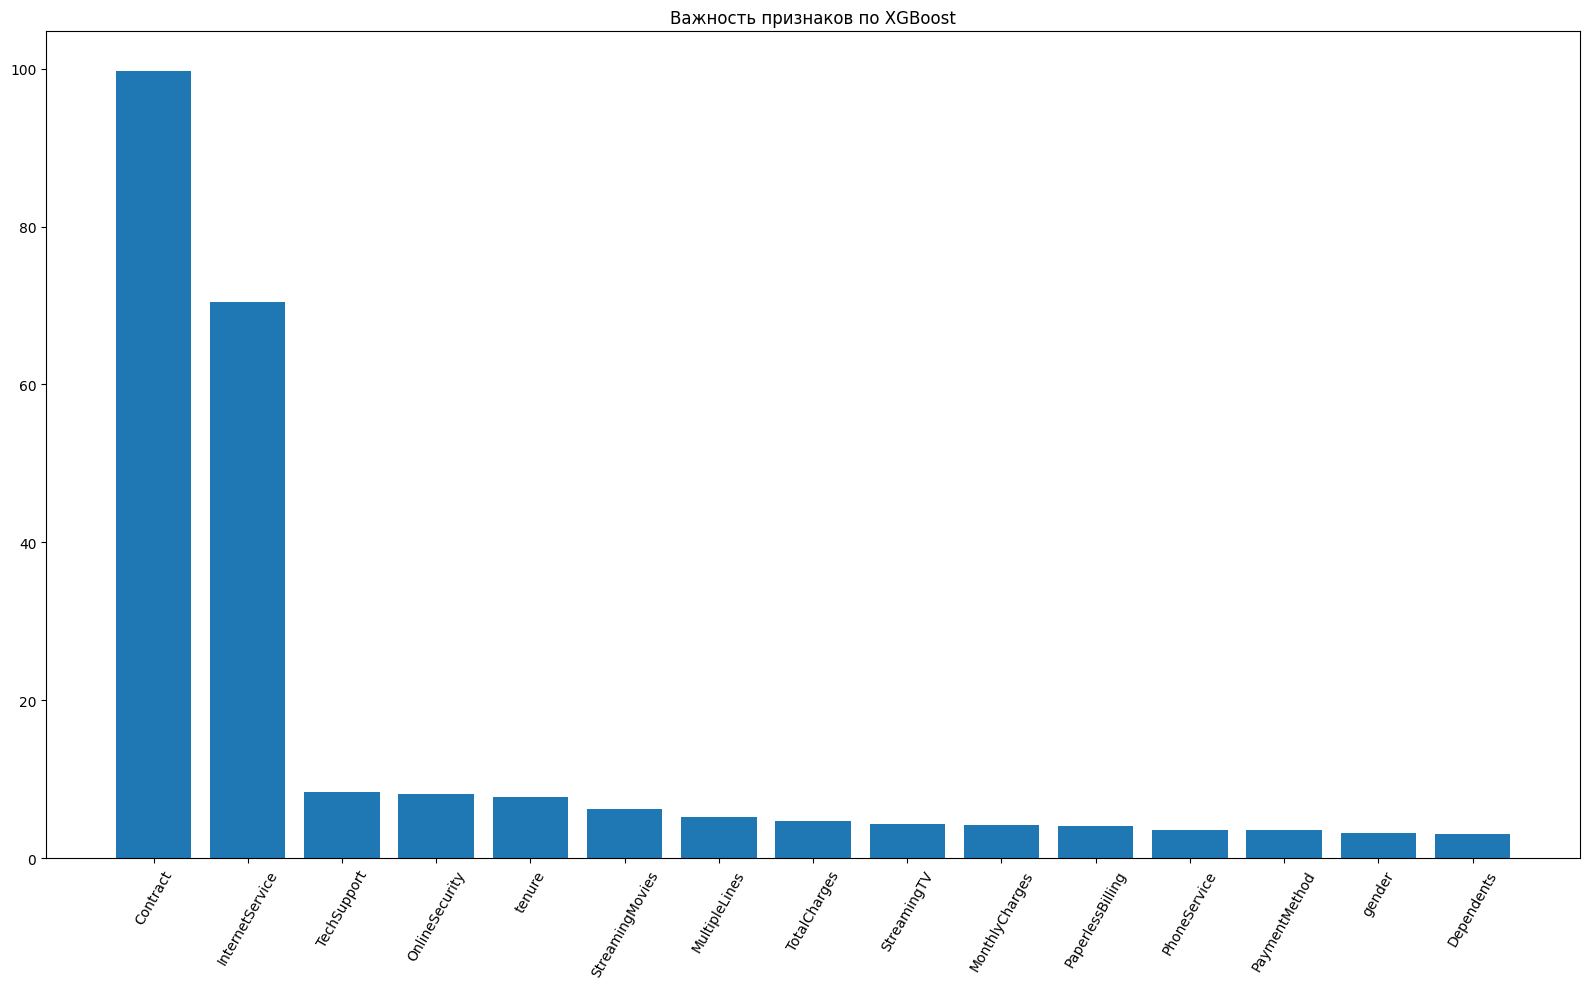

In [149]:
ft_importance = xgb_model.get_score(importance_type="gain")
dt = pd.Series(ft_importance).sort_values(ascending=False).head(15)

plt.figure(figsize=(16,10))
plt.title("Важность признаков по XGBoost")
plt.bar(
    dt.index,
    dt.values
)
plt.xticks(rotation=60)
plt.tight_layout()

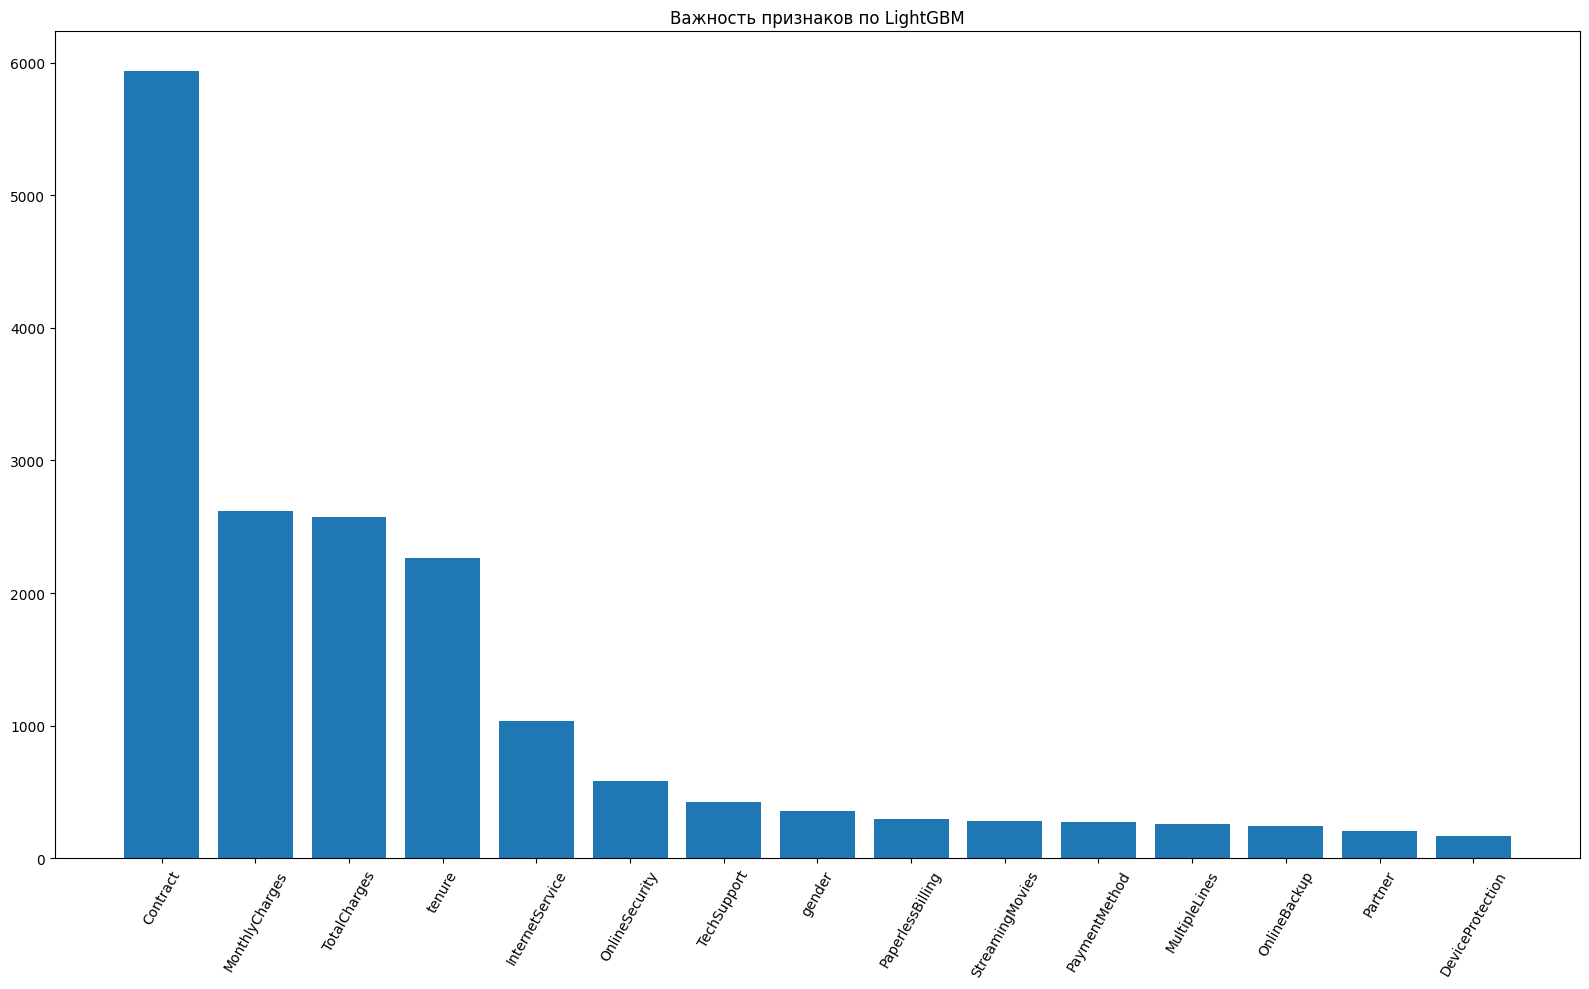

In [150]:
ft_importance = lgbm_model.feature_importance(importance_type="gain")
order = np.argsort(ft_importance)[::-1][:15]

plt.figure(figsize=(16,10))
plt.title("Важность признаков по LightGBM")
plt.bar(
    X_train.columns[order],
    ft_importance[order]
)
plt.xticks(rotation=60)
plt.tight_layout()

## 8. Фильтрация признаков

Удалите из датасета наименее важные на ваш взгляд признаки и обучите модели случайного леса и градиентного бустинга на полученном наборе данных. Как изменилось качество после фильтрации?

Уберем все признаки услуги и предскажем без них.

In [218]:
cat_columns = ['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

Обучим catboost

In [219]:
y = df["Churn"]
X = df.drop(columns=["Churn", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

for col in cat_columns:
    X_train[col] = X_train[col].astype("category")

    X_test[col] = X_test[col].astype("category")

In [220]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

train_catboost = Pool(X_train, label=y_train, cat_features=cat_columns)
test_catboost = Pool(X_test, label=y_test, cat_features=cat_columns)
cat_model = CatBoostClassifier(random_state=42, max_depth=7, n_estimators=200, class_weights={0: 1, 1: pos_weight}, learning_rate=0.02, verbose=0)
cat_model.fit(train_catboost)

y_pred_ct = cat_model.predict(X_test)
y_pred_prob_ct = cat_model.predict_proba(X_test)[:, 1]

print("CatBoost")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ct)}")
print(f"F1-score: {f1_score(y_test, y_pred_ct)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_ct)}")
print(classification_report(y_test, y_pred_ct))
print()

CatBoost
Accuracy: 0.7423704755145494
F1-score: 0.62148070907195
ROC-AUC: 0.8435764292541786
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409




Обучим теперь случайный лес

In [221]:
X_train, X_test, y_train, y_test = preprocess_data(df.copy(), cat_columns)

X_train.drop(columns=["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"], inplace=True)
X_test.drop(columns=["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"], inplace=True)

Размер тренировочной выборки: (5634, 33)
Размер тестовой выборки: (1409, 33)


In [227]:
forest_model = RandomForestClassifier(n_estimators=200,  max_depth=7, random_state=42, class_weight={0: 1, 1: pos_weight})

forest_model.fit(X_train, y_train)

y_pred = forest_model.predict(X_test)
y_pred_prob = forest_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1-score: {f1_score(y_test, y_pred)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob)}")
print(classification_report(y_test, y_pred))
print()

Accuracy: 0.7572746628814763
F1-score: 0.6314655172413793
ROC-AUC: 0.8435428453331265
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409




## 9. Выводы
- Сравните качество моделей
- Сделайте вывод, какая модель лучше справилась
- Подумайте, почему именно так

Сравним две последние модели catboost и random forest.

`случайный лес` - на чуть-чуть лучше справился. classification report немного лучше чем у `catboost`. Но гиперпараметры не оптимизировались сильно, и `catboost` и `случайный лес` можно еще тоньше настроить, тогда результаты могут изменится и качество вырасти. Почему именно так (случайный лес лучше catboost), трудно сказать, возможно случайный лес в силу работы своего алгоритма, смог уловить немного больше информации нежели бустинг. Это естественно и нормально, когда кажется , что бустинги ожидаемо должны давать лучший результат, но на самом деле другие алгоритмы им не уступают порой. Все зависит от данных, с которыми мы работаем.